# Part one 

## a)
- import the required libraries 

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns

- Create variables N = 10000 and S = 1 as given in the question..


In [17]:
N = 10000
S = 1

- Define functions for f(x) and random walk metropolis.

In [13]:
def f(x0):
    return 1/2 * np.exp(-abs(x0))

def random_walk_metropolis(number, standard_dev, x0 = 0):
    sample_space = []
    for i in range(number):
        x_random = x0 + np.random.normal(0,standard_dev)
        ratio = math.log(f(x_random)) - math.log(f(x0))
        u = math.log(np.random.rand())
        if  u < ratio:
            x0 = x_random
        sample_space.append(x0)
    return np.array(sample_space)

- Using the functions defined above, sub in values of N and S to generate samples to find sample mean and standard deviation.

In [23]:
sample_space = random_walk_metropolis(N, S)
sample_mean = np.mean(sample_space)
sample_std_dev = np.std(sample_space)
print(f"Sample Mean : {sample_mean}")
print(f"Sample Standard Deviation : {sample_std_dev}")

Sample Mean : 0.03224440258134229
Sample Standard Deviation : 1.4282132073085072


- Using the values generated, construct a histogram and kernel density plot and overlay graph of f(x).

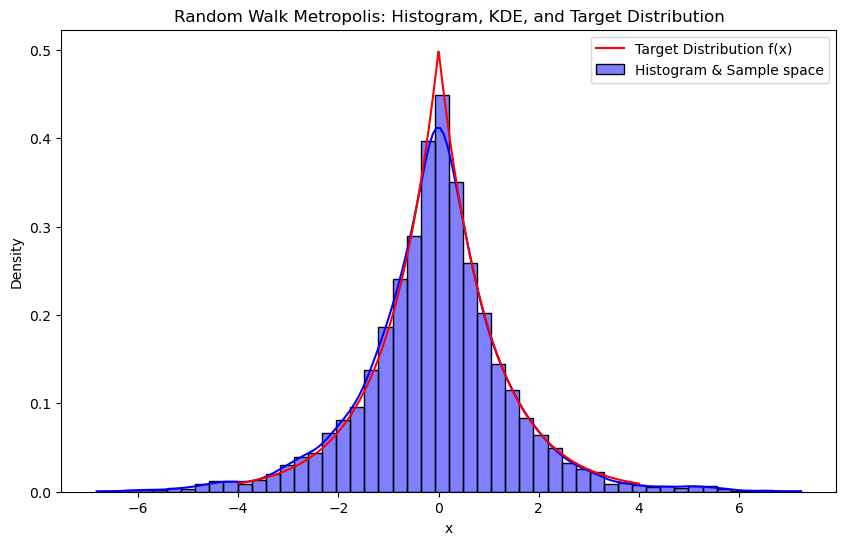

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(sample_space, bins=50, kde=True, color='blue', stat='density', label='Histogram & Sample space')

x = np.linspace(-4, 4, 1000)
plt.plot(x, f(x), color='red', label='Target Distribution f(x)')
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.title("Random Walk Metropolis: Histogram, KDE, and Target Distribution")
plt.show()

## b)

- Define functions generate_chains for creating chains and calculate_rhat to apply the procedure given.

In [48]:
def generate_chains(number, standard_dev, J):
    total_chains = []
    for j in range(J):
        x0 = J
        chain = random_walk_metropolis(number, standard_dev,x0 = x0)
        total_chains.append(chain)
    return np.array(total_chains)
    
    
def calculate_rhat(total_chains, N, J):
    Mj = np.mean(total_chains, axis = 1)
    Vj = np.var(total_chains, axis = 0, ddof=1)
    W = np.mean(Vj)
    M = np.mean(Mj)
    B = np.mean((Mj - M)**2)
    r_hat = np.sqrt((B + W)/ W)
    return r_hat
    

- Change parameter N,J and s to new values given. Generate values for s in the interval between 0.001 and 1.

In [51]:
N = 2000
J = 4
s = 0.001
s_values = np.linspace(0.001, 1, 75)

- Generate values for r hat and store it in array rhat_values.

In [54]:
rhat_values = []
for s in s_values:
    total_chains = np.array([random_walk_metropolis(N, s, x0=i) for i in range(J)])
    rhat = calculate_rhat(total_chains, N, J)
    rhat_values.append(rhat)


- R hat value for the random walk Metropolis algorithm with N = 2000, s = 0.001 and J = 4 is equal to

In [59]:
r = calculate_rhat(total_chains, N, J)
print(f"R Value: {r}")

R Value: 1.006162035961908


- plotting the graph of values of rhat over a grid of s values in the interval between 0.001 and 1.

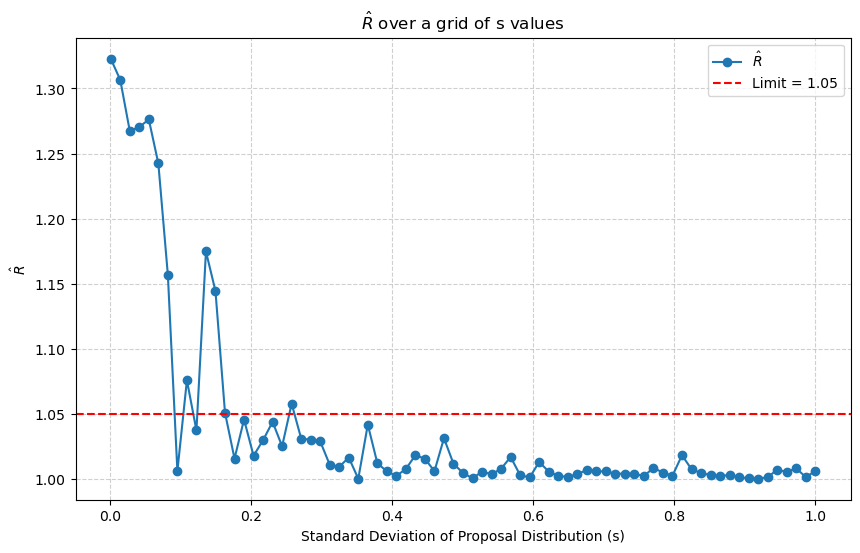

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(s_values, rhat_values, marker='o', label=r"$\hat{R}$")
plt.axhline(1.05, color='red', linestyle='--', label="Limit = 1.05")
plt.xlabel("Standard Deviation of Proposal Distribution (s)")
plt.ylabel(r"$\hat{R}$")
plt.title(r"$\hat{R}$ over a grid of s values")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()
